# Basel MRI Dataset

Akinci D’Antonoli, T., Todea, R. A., Leu, N., Datta, A. N., Stieltjes, B., Pruefer, F., & Wasserthal, J. (2023). Development and evaluation of deep learning models for automated estimation of myelin maturation using pediatric brain MRI scans. Radiology: Artificial Intelligence, 5(5), e220292.

https://pubs.rsna.org/doi/10.1148/ryai.220292

https://zenodo.org/records/8055666

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import seaborn as sns
import os
import json
import utils as ut
from pathlib import Path
import subprocess
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from nibabel.processing import resample_to_output,resample_from_to

In [6]:
# Load the dataset
file_path = os.path.join("..", "..", "Datasets", "Basel_mri", "meta.csv")
df = pd.read_csv(file_path, sep=';')
df.describe(include='all')

,image_id,myelinisation,age,age_corrected,doctor_predicted_age,diagnosis,group
count,833,833,833.000000,833.000000,833.000000,833,833
unique,833,2,NaN,NaN,NaN,73,2
top,s0833,normal,NaN,NaN,NaN,normal,train
freq,1,829,NaN,NaN,NaN,565,710
mean,NaN,NaN,13.722689,13.668667,13.669868,NaN,NaN
std,NaN,NaN,11.754957,11.795154,11.795748,NaN,NaN
min,NaN,NaN,0.000000,-1.000000,-1.000000,NaN,NaN
25%,NaN,NaN,3.000000,3.000000,2.000000,NaN,NaN
50%,NaN,NaN,12.000000,12.000000,12.000000,NaN,NaN
75%,NaN,NaN,24.000000,24.000000,24.000000,NaN,NaN


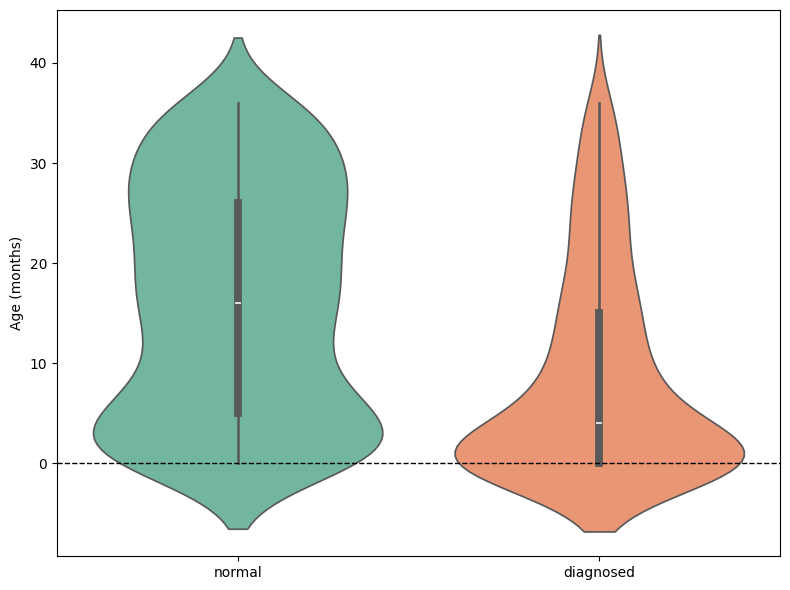

In [3]:
# Create a new column for group labels
df['diagnosis_group'] = df['diagnosis'].apply(lambda x: 'normal' if x.lower() == 'normal' else 'diagnosed')

# Make the violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(x='diagnosis_group', y='age', hue='diagnosis_group', data=df, palette='Set2', legend=False)
plt.axhline(y=0, color='k', linestyle='--', lw=1)

plt.xlabel('')
plt.ylabel('Age (months)')
plt.tight_layout()
plt.show()

In [4]:
counts = df[df['age'] < 10].groupby('diagnosis_group').size()
print(counts)

diagnosis_group
diagnosed    174
normal       208
dtype: int64


## Segmentation

First preparation of the txt files with all paths.

In [5]:
basel_win    = Path(r"../../Datasets/Basel_mri")
seg_win    = Path(r"../../Datasets/Basel_mri_synthseg")

# make directory for the output
seg_win.mkdir(parents=True, exist_ok=True)

RESAMPLE_T1_FIRST = True
VOX_MM = (0.5, 0.5, 0.5)  # target isotropic spacing
resampled_root = basel_win / f"resampled_{VOX_MM[0]:.1f}mm"
if RESAMPLE_T1_FIRST:
    resampled_root.mkdir(parents=True, exist_ok=True)

inputs, outputs = [], []

# Collect scans & plan matches
for img in basel_win.rglob("*t1.nii*"):
    rel_path = img.relative_to(basel_win)
    if 'atlas' not in str(rel_path):            
        out_img  = seg_win / rel_path                  

        # ensure the parent folder for this output exists
        out_img.parent.mkdir(parents=True, exist_ok=True)

        # if enabled, write a resampled copy and use that as input
        src_for_synthseg = img
        if RESAMPLE_T1_FIRST:
            resampled_path = (resampled_root / rel_path)
            resampled_path.parent.mkdir(parents=True, exist_ok=True)
            if not resampled_path.exists():
                t1_img = nib.load(str(img))
                resampled_t1 = resample_to_output(t1_img, voxel_sizes=VOX_MM)  # cubic by default
                nib.save(resampled_t1, str(resampled_path))
            src_for_synthseg = resampled_path

        inputs.append(ut.win2posix(str(src_for_synthseg)))
        outputs.append(ut.win2posix(str(out_img)))

# Write the two list files
in_list  = basel_win / "synthseg_inputs.txt"
out_list = basel_win / "synthseg_outputs.txt"

in_list.write_text("\n".join(inputs))
out_list.write_text("\n".join(outputs))

print(f"Wrote {len(inputs)} lines to:")
print("  ", in_list)
print("  ", out_list)

Wrote 833 lines to:
   ..\..\Datasets\Basel_mri\synthseg_inputs.txt
   ..\..\Datasets\Basel_mri\synthseg_outputs.txt


In [20]:
def plot_mri_images(img_a, img_b, title_a="A", title_b="B"):
    """
    Show corresponding sagittal/coronal/axial middle slices of two images.
    - Reorients both to RAS.
    - Resamples img_b to img_a's grid so slices match anatomically.
    """
    
    a = img_a.get_fdata()
    b = img_b.get_fdata()

    # helper to extract middle slices
    def midslices(arr):
        i = arr.shape[0] // 2
        j = arr.shape[1] // 2
        k = arr.shape[2] // 2
        # transpose/flip for display so axial is "up is posterior" typical
        sag = np.flipud(arr[i, :, :].T)
        cor = np.flipud(arr[:, j, :].T)
        axi = np.flipud(arr[:, :, k].T)
        return sag, cor, axi

    a_sag, a_cor, a_axi = midslices(a)
    b_sag, b_cor, b_axi = midslices(b)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    titles = ['Sagittal', 'Coronal', 'Axial']

    for idx, slc in enumerate([a_sag, a_cor, a_axi]):
        axes[0, idx].imshow(slc, cmap='gray')
        axes[0, idx].set_title(f'{title_a} {titles[idx]}')
        axes[0, idx].axis('off')

    for idx, slc in enumerate([b_sag, b_cor, b_axi]):
        axes[1, idx].imshow(slc, cmap='gray')
        axes[1, idx].set_title(f'{title_b} {titles[idx]}')
        axes[1, idx].axis('off')

    plt.tight_layout()
    plt.show()

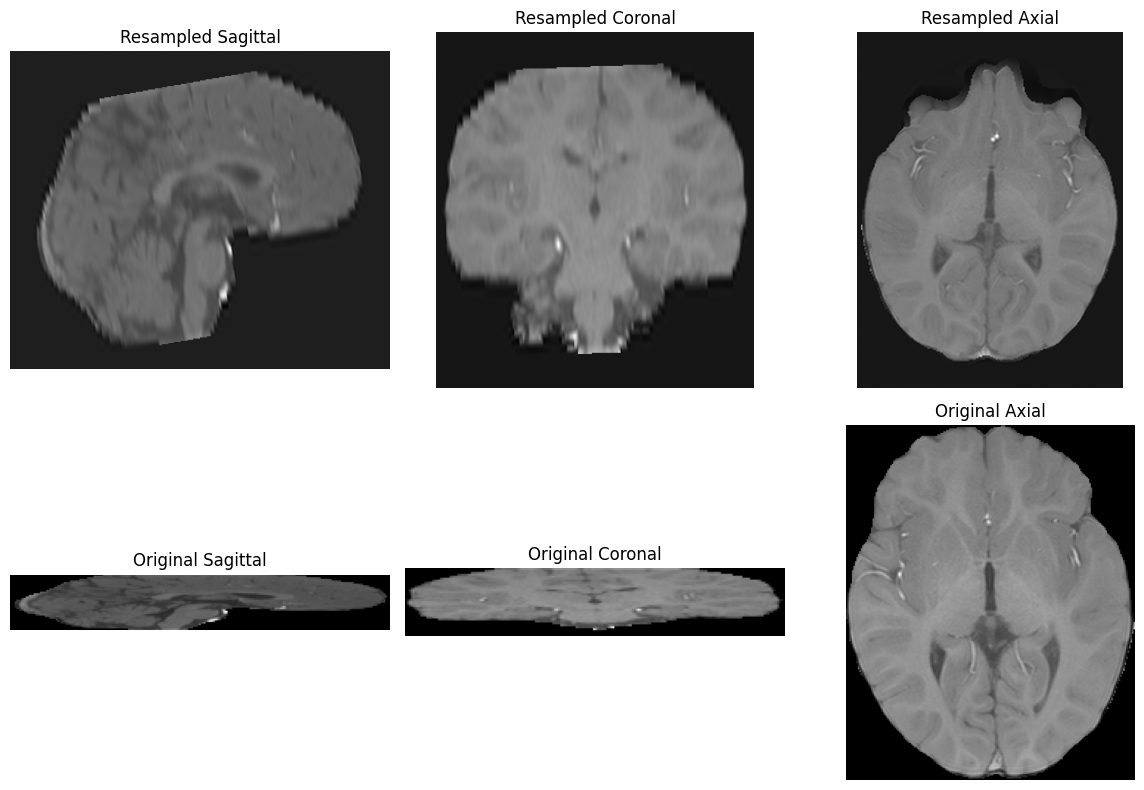

In [21]:
test_resampled = nib.load(r"..\..\Datasets\Basel_mri\resampled_0.5mm\s0001\t1.nii.gz")
test_org       = nib.load(r"..\..\Datasets\Basel_mri\s0001\t1.nii.gz")

plot_mri_images(test_resampled, test_org, title_a="Resampled", title_b="Original")

Create txt files with the paths for volumn and qc.

In [22]:
vol_list    = basel_win / "synthseg_volumes.txt"
qc_list     = basel_win / "synthseg_qc.txt"

# Read your existing inputs & outputs
with in_list.open() as fi, out_list.open() as fo:
    ins  = [l.strip() for l in fi]
    outs = [l.strip() for l in fo]

vols, qcs = [], []
for outp in outs:
    # replace the .nii or .nii.gz extension with _vol.csv / _qc.csv
    if outp.lower().endswith(".nii.gz"):
        base = outp[:-7]    # drop ".nii.gz"
    else:
        base = outp.rsplit(".", 1)[0]
    vols.append(base + "_vol.csv")
    qcs .append(base + "_qc.csv")

# Write them out
vol_list.write_text("\n".join(vols) + "\n")
qc_list.write_text( "\n".join(qcs)  + "\n")

print(f"{len(vols)} volume paths written to: {vol_list}")
print(f"{len(qcs )} QC paths written to: {qc_list }")

833 volume paths written to: ..\..\Datasets\Basel_mri\synthseg_volumes.txt
833 QC paths written to: ..\..\Datasets\Basel_mri\synthseg_qc.txt


Check how many files were already processed:

In [23]:
def get_scan_id(pp: str) -> str:
    """
    From any POSIX path like
      /c/.../BOB[_segmented]/sub-116056/ses-3mo/anat/...filename...
    extract the chunk 'sub-116056/ses-3mo/anat'
    so that all three logs collapse to the same key.
    """
    parts = pp.lstrip("/").split("/")
    return parts[-2]

def load_scan_ids(log_txt: Path) -> set[str]:
    """
    Read each non-blank line from the POSIX-style log file,
    convert to Windows path, check it really exists,
    and then return the set of scan_ids for those that do.
    """
    if not log_txt.exists():
        return set()

    ids = set()
    for ln in log_txt.read_text().splitlines():
        pp = ln.strip()
        if not pp:
            continue
        winp = ut.posix2win(pp)
        if winp.exists():
            ids.add(get_scan_id(pp))
    return ids

In [48]:
# load the master inputs
in_list = basel_win / "synthseg_inputs.txt"
inputs = [l.strip() for l in in_list.read_text().splitlines() if l.strip()]

# build the set of scan IDs for each log file
out_ids = load_scan_ids(out_list)
vol_ids = load_scan_ids(vol_list)
qc_ids  = load_scan_ids(qc_list)

fully_done_ids = out_ids & vol_ids & qc_ids
print(f"{len(fully_done_ids)} scans have all 3 outputs.")

pending = [
    pp for pp in inputs
    if get_scan_id(pp) not in fully_done_ids
]
print(f"{len(pending)} scans still need processing.")

620 scans have all 3 outputs.
213 scans still need processing.


### run Segmentation

In [49]:
FILES_TO_PROCESS = None  # set to None to process all pending

In [28]:
# Check and start Docker if necessary
if not ut.is_docker_running():
    print("Docker is not running. Starting it now...")
    ut.start_docker()
else:
    print("Docker is running.")

Docker is running.


In [50]:
def filter_by_pending(master_txt: Path, dest_txt: Path, top_n: int | None = None):
    """
    Read the master list, filter by pending IDs,
    optionally keep only the top N lines.
    """
    lines = [
        ln.strip()
        for ln in master_txt.read_text().splitlines()
        if ln.strip() and get_scan_id(ln) in pending_ids
    ]

    if top_n is not None:
        lines = lines[:top_n]

    dest_txt.write_text("\n".join(lines) + "\n")
    print(f"Wrote {len(lines)} lines to {dest_txt.name}")

in_list  = basel_win / "synthseg_inputs.txt"
out_list = basel_win / "synthseg_outputs.txt"
vol_list = basel_win / "synthseg_volumes.txt"
qc_list  = basel_win / "synthseg_qc.txt"

# choose which pending to run now
selected_pending = pending[:FILES_TO_PROCESS] if FILES_TO_PROCESS is not None else pending
selected_ids = { get_scan_id(pp) for pp in selected_pending }

# write inputs pending using the *selected* list directly (keeps order identical to 'pending')
pending_inputs = basel_win / "synthseg_inputs_pending.txt"
pending_inputs.write_text("\n".join(selected_pending) + "\n")

# temporarily point the filter to the same ID set
pending_ids = selected_ids
filter_by_pending(out_list, basel_win / "synthseg_outputs_pending.txt")
filter_by_pending(vol_list, basel_win / "synthseg_volumes_pending.txt")
filter_by_pending(qc_list,  basel_win / "synthseg_qc_pending.txt")


Wrote 213 lines to synthseg_outputs_pending.txt
Wrote 213 lines to synthseg_volumes_pending.txt
Wrote 213 lines to synthseg_qc_pending.txt


In [51]:
in_list_pending  = basel_win / "synthseg_inputs_pending.txt"
out_list_pending = basel_win / "synthseg_outputs_pending.txt"
vol_list_pending = basel_win / "synthseg_volumes_pending.txt"
qc_list_pending  = basel_win / "synthseg_qc_pending.txt"

posix_root = ut.win2posix(str(basel_win.parent)) 
posix_in   = ut.win2posix(str(in_list_pending))
posix_out  = ut.win2posix(str(out_list_pending))
posix_vol    = ut.win2posix(str(vol_list_pending))
posix_qc     = ut.win2posix(str(qc_list_pending))

# Build & run
cmd = [
    "docker", "run", "--rm",
    "-v", f"{posix_root}:{posix_root}",
    "cookpa/synthseg:conda-0.1",
    "--i", posix_in,
    "--o", posix_out,
    "--vol", posix_vol,
    "--qc", posix_qc,
    "--robust", "--cpu", "--threads", "8",
]

print("Running SynthSeg on all listed scans…")
subprocess.run(cmd, check=True)
print("Done.")

Running SynthSeg on all listed scans…
Done.


In [ ]:
for pending_file in basel_win.glob("synthseg_*_pending.txt"):
    try:
        pending_file.unlink()
        print(f"Deleted {pending_file.name}")
    except Exception as e:
        print(f"Failed to delete {pending_file.name}: {e}")

### Subfolder for all masks

In [52]:
# Freesurfer label mapping
index_to_label = {}
with open('FreeSurferColorLUT.txt', 'r') as file:
    for line in file:
        # comments or empty
        if line.startswith('#') or not line.strip():
            continue

        parts = line.split()
        index = int(parts[0])
        label_name = ' '.join(parts[1:-4])
        index_to_label[index] = label_name

In [53]:
out_list  = basel_win / "synthseg_outputs.txt"
# out_list  = basel_win / "synthseg_outputs_pending.txt"

# Loop through each segmented file
with out_list.open("r") as f:
    for line in f:
        posix_seg = line.strip()
        win_seg   = ut.posix2win(posix_seg)

        # create a segmentation_outputs folder alongside the .nii.gz
        sess_dir  = win_seg.parent / "segmentation_outputs"
        sess_dir.mkdir(exist_ok=True)

        # load the segmentation volume
        img   = nib.load(str(win_seg))
        data  = img.get_fdata().astype(int)
        labels = np.unique(data)
        labels = labels[labels != 0]  # skip background

        print(f"[{win_seg.stem}] saving masks for labels: {labels}")

        # build a CSF union mask 
        csf_mask = np.zeros(data.shape, dtype=bool)

        for lbl in labels:
            name = index_to_label.get(int(lbl))
            if not name:
                print(f"skipping unknown label {lbl}")
                continue

            mask = (data == lbl).astype(np.uint8)

            # accumulate CSF voxels 
            if "csf" in name.lower():
                csf_mask |= (mask > 0)

            mask_img = nib.Nifti1Image(mask, img.affine, img.header)
            mask_fp  = sess_dir / f"{lbl:03d}_{name}.nii.gz"
            nib.save(mask_img, str(mask_fp))
            print(f"wrote {mask_fp.name}")

        # whole-brain minus CSF
        wb_mask = data > 0
        wb_minus_csf = (wb_mask & (~csf_mask)).astype(np.uint8)

        # robust base name for output (handles .nii and .nii.gz)
        if win_seg.name.lower().endswith(".nii.gz"):
            base = win_seg.name[:-7]
        else:
            base = win_seg.stem

        wb_fp = sess_dir / f"{base}_whole_brain_minus_CSF.nii.gz"
        nib.save(nib.Nifti1Image(wb_minus_csf, img.affine, img.header), str(wb_fp))
        print(f"wrote {wb_fp.name}")


[t1.nii] saving masks for labels: [ 2  3  4  5  7  8 10 11 12 13 14 15 16 17 18 24 26 28 41 42 43 44 46 47
 49 50 51 52 53 54 58 60]
wrote 002_Left-Cerebral-White-Matter.nii.gz
wrote 003_Left-Cerebral-Cortex.nii.gz
wrote 004_Left-Lateral-Ventricle.nii.gz
wrote 005_Left-Inf-Lat-Vent.nii.gz
wrote 007_Left-Cerebellum-White-Matter.nii.gz
wrote 008_Left-Cerebellum-Cortex.nii.gz
wrote 010_Left-Thalamus.nii.gz
wrote 011_Left-Caudate.nii.gz
wrote 012_Left-Putamen.nii.gz
wrote 013_Left-Pallidum.nii.gz
wrote 014_3rd-Ventricle.nii.gz
wrote 015_4th-Ventricle.nii.gz
wrote 016_Brain-Stem.nii.gz
wrote 017_Left-Hippocampus.nii.gz
wrote 018_Left-Amygdala.nii.gz
wrote 024_CSF.nii.gz
wrote 026_Left-Accumbens-area.nii.gz
wrote 028_Left-VentralDC.nii.gz
wrote 041_Right-Cerebral-White-Matter.nii.gz
wrote 042_Right-Cerebral-Cortex.nii.gz
wrote 043_Right-Lateral-Ventricle.nii.gz
wrote 044_Right-Inf-Lat-Vent.nii.gz
wrote 046_Right-Cerebellum-White-Matter.nii.gz
wrote 047_Right-Cerebellum-Cortex.nii.gz
wrote 04

## Fractal dimension and volume calculation

In [ ]:
def get_volume(seg_path: str) -> float:
    """
    Calculate the volume in mL of the non-zero voxels in the segmentation file.
    """
    try:  
        img = nib.load(seg_path)
        data = img.get_fdata()
        zooms = img.header.get_zooms()[:3] # mm
        voxvol_mm3 = float(zooms[0] * zooms[1] * zooms[2]) # mm^3 per voxel
        mask = data > 0 
        vol_ml = mask.sum() * voxvol_mm3 / 1000.0 # convert to mL
        return float(vol_ml)
    except Exception as e:
        print(f"[VOLUME ERROR] {seg_path}: {e}")
        return np.nan

def _idnum(pid: str) -> int:
    pid = pid.lower()
    if pid.startswith("s"):
        pid = pid[1:]
    return int(pid)  # assumes numeric after 's' (e.g., "0313")

In [21]:
data_folder = Path("../../Datasets/Basel_mri_synthseg")

OVERWRITE_JSON = False  # set True to recompute a participant even if JSON exists
ONLY_IDS: set[str] | None = None             # e.g. {"s0313","s0317"} or None
ID_RANGE: tuple[str, str] | None = None #("s0501","s0600")   # or None to disable

# loop over whole-brain dseg files
for dseg in data_folder.rglob("*t1.nii.gz"):
    participant = dseg.parents[0].name

    if ONLY_IDS is not None and participant not in ONLY_IDS:
        continue
    if ID_RANGE is not None:
        start_num = _idnum(ID_RANGE[0])
        end_num   = _idnum(ID_RANGE[1])
        pnum      = _idnum(participant)
        if not (start_num <= pnum <= end_num):
            continue

    part_dir = dseg.parent
    out_json = part_dir / "fd_vol_results.json"  

    if out_json.exists() and not OVERWRITE_JSON:  # skip if already processed
        print(f"processing - {participant} (skip: JSON exists)")
        continue

    print(f"processing - {participant}")
    part_entries = []  # collect entries for this participant's JSON

    # whole-brain volume (mL)
    wb_vol_ml = get_volume(str(dseg))  

    # whole-brain FD
    try:
        fd, (mfs, Mfs), _ = ut.fractal_analysis(str(dseg), verbose=False)
    except Exception as e:
        print(f"[FD ERROR] {dseg}: {e}")
        fd, mfs, Mfs = np.nan, np.nan, np.nan
    wb_row = {
        'image_id': participant,
        'label':         None,
        'name':          'whole_brain',
        'fd':            fd,
        'min_box_size':  mfs,
        'max_box_size':  Mfs,
        'volume_ml':     wb_vol_ml,
    }
    part_entries.append(wb_row)     

    # per-mask FD + volume
    mask_dir = dseg.parent / "segmentation_outputs"
    if not mask_dir.exists():
        print(f" no masks found for {dseg.stem}, skipping masks")
        # write empty JSON to indicate processing done but no masks
        out_json.write_text(json.dumps(part_entries, indent=2))
        continue

    for mask_fp in mask_dir.glob("*.nii.gz"):
        stem = mask_fp.stem
        stem = stem.replace(".nii","")  

        # Gracefully handle special files (e.g., whole_brain_minus_CSF.nii.gz)
        if stem and stem[0].isdigit():   # expected "###_LabelName"
            lbl_str, name = stem.split("_", 1)
            lbl = int(lbl_str)
        else:
            lbl, name = None, stem      

        # volume (mL)
        vol_ml = get_volume(str(mask_fp))

        # FD
        try:
            fd, (mfs, Mfs), _ = ut.fractal_analysis(str(mask_fp), verbose=False)
        except Exception as e:
            print(f"[FD ERROR] {mask_fp}: {e}")
            fd, mfs, Mfs = np.nan, np.nan, np.nan

        row = {
            'image_id': participant,
            'label':         lbl,
            'name':          name,
            'fd':            fd,
            'min_box_size':  mfs,
            'max_box_size':  Mfs,
            'volume_ml':     vol_ml
        }
        part_entries.append(row)

    # write per-participant JSON at the end of this participant
    out_json.write_text(json.dumps(part_entries, indent=2))
    print(f" wrote {out_json.name} with {len(part_entries)} entries")


processing - s0001
FD automatically selected: 2.8181
FD automatically selected: 2.4802
FD automatically selected: 2.5294
FD automatically selected: 1.4359
FD automatically selected: 1.4233
FD automatically selected: 2.2111
FD automatically selected: 2.5186
FD automatically selected: 2.2378
FD automatically selected: 2.0209
FD automatically selected: 2.159
FD automatically selected: 1.9415
FD automatically selected: 1.7298
FD automatically selected: 1.8398
FD automatically selected: 2.3503
FD automatically selected: 2.0554
FD automatically selected: 1.9474
FD automatically selected: 2.099
FD automatically selected: 1.7886
FD automatically selected: 2.0858
FD automatically selected: 2.4759
FD automatically selected: 2.5267
FD automatically selected: 1.9168
FD automatically selected: 1.1347
FD automatically selected: 2.1851
FD automatically selected: 2.5159
FD automatically selected: 2.22
FD automatically selected: 2.011
FD automatically selected: 2.1663
FD automatically selected: 1.9605


### Combine results

In [2]:
def combine_all_results(root: Path, filename: str = "fd_vol_results.json") -> pd.DataFrame:
    """
    Read every per-participant results JSON (default: fd_vol_results.json)
    and return a tidy DataFrame. Supports both:
      - list[...] (your current writer)
      - {"entries": [...]} (fallback)
    """
    rows = []
    for res_fp in root.rglob(filename):
        try:
            payload = json.loads(res_fp.read_text())
            if isinstance(payload, list):
                entries = payload
            elif isinstance(payload, dict):
                entries = payload.get("entries", [])
            else:
                entries = []

            pid = res_fp.parent.name  # sXXXX
            for r in entries:
                r.setdefault("image_id", pid)
            rows.extend(entries)
        except Exception as e:
            print(f"[WARN] failed to read {res_fp}: {e}")

    df = pd.DataFrame(rows)

    # normalise dtypes if present
    for col in ("fd", "min_box_size", "max_box_size", "volume_ml"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # drop perfect duplicates
    if not df.empty:
        df = df.drop_duplicates()

    return df

# combine all results in a dataframe
data_folder = Path("../../Datasets/Basel_mri_synthseg")
df_all = combine_all_results(data_folder)
print(df_all.shape)
df_all.head()

(25435, 7)


,image_id,label,name,fd,min_box_size,max_box_size,volume_ml
0,s0001,NaN,whole_brain,2.8181,1.0,16.0,1064.972
1,s0001,2.0,Left-Cerebral-White-Matter,2.4802,1.0,16.0,151.670
2,s0001,3.0,Left-Cerebral-Cortex,2.5294,1.0,16.0,221.491
3,s0001,4.0,Left-Lateral-Ventricle,1.4359,4.0,64.0,3.390
4,s0001,5.0,Left-Inf-Lat-Vent,1.4233,1.0,16.0,0.305


In [5]:
# some checks
print(f"unique image ids: {df_all['image_id'].nunique()}")

print("\nIDs/labels with FD = NaN:")
df_all[df_all['fd'].isna()][['image_id', 'label', 'name']]

unique image ids: 833

IDs/labels with FD = NaN:


,image_id,label,name
9725,s0313,NaN,whole_brain
9726,s0313,NaN,t1_whole_brain_minus_CSF


In [8]:
df_results_merged = df_all.merge(
    df,
    on=['image_id'],
    how='left'
)
df_results_merged.to_csv("outputs/basel_synthseg_fd_volumes.csv", index=False)
df_results_merged.head()

,image_id,label,name,fd,min_box_size,max_box_size,volume_ml,myelinisation,age,age_corrected,doctor_predicted_age,diagnosis,group
0,s0001,NaN,whole_brain,2.8181,1.0,16.0,1064.972,normal,22,22,22,normal,train
1,s0001,2.0,Left-Cerebral-White-Matter,2.4802,1.0,16.0,151.670,normal,22,22,22,normal,train
2,s0001,3.0,Left-Cerebral-Cortex,2.5294,1.0,16.0,221.491,normal,22,22,22,normal,train
3,s0001,4.0,Left-Lateral-Ventricle,1.4359,4.0,64.0,3.390,normal,22,22,22,normal,train
4,s0001,5.0,Left-Inf-Lat-Vent,1.4233,1.0,16.0,0.305,normal,22,22,22,normal,train
